# import and def

In [5]:
import os
import platform
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from tqdm.auto import trange, tqdm
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# --- Device Setup ---
def get_device(skip_apple_silicon=False):
    if torch.cuda.is_available():
        device = "cuda"
        device_name = f"CUDA GPU ({torch.cuda.get_device_name(0)})"
    elif platform.processor() == 'arm' and platform.system() == 'Darwin' and not skip_apple_silicon:
        device = "mps"  # For Apple Silicon using MPS
        device_name = "Apple Silicon (MPS)"
    else:
        device = "cpu"
        device_name = "CPU"
    return device, device_name

# --- Load GPT2 Model & Tokenizer ---
def load_gpt2_model(device):
    mode_name = "gpt2"
    # mode_name = "gpt2-xl" #CRASHES COMPUTER!!!!!
    # mode_name = "gpt2-medium"
    model = GPT2LMHeadModel.from_pretrained(mode_name)  # gpt2-small
    tokenizer = GPT2Tokenizer.from_pretrained(mode_name)
    model.to(device)
    model.config.output_hidden_states = True  # Enable hidden states in the output
    return model, tokenizer

# --- Get Activations from a Specified Transformer Layer ---
def get_activation(model, input_ids, layer_index):
    outputs = model(input_ids)  # forward pass; hidden_states is a tuple: (embeddings, block1, block2, ...)
    hidden_states = outputs.hidden_states
    # Select the hidden state from the chosen layer (e.g., layer 7)
    activations = hidden_states[layer_index]  # shape: [batch_size, seq_len, hidden_size]
    return activations

# --- Compute Activation Similarity ---
def compute_activation_similarity(activations):
    """
    Average pools over the sequence length so each sample becomes a single vector,
    then computes the dot product similarity between samples.
    """
    batch_size = activations.size(0)
    pooled = activations.mean(dim=1)  # shape: [batch_size, hidden_size]
    similarity_matrix = torch.matmul(pooled, pooled.t())
    return similarity_matrix, pooled

# --- Compute Empirical NTK ---
def compute_empirical_ntk(model, input_ids):
    """
    For each sample, computes gradients of the language-model loss (using the sample as its own label)
    and then forms the NTK matrix from the flattened gradients.
    """
    model.train()
    batch_size = input_ids.size(0)
    grad_list = []
    for i in range(batch_size):
        model.zero_grad()
        sample_ids = input_ids[i].unsqueeze(0)  # shape: [1, seq_len]
        # GPT2 will automatically shift tokens when labels are provided.
        output = model(sample_ids, labels=sample_ids)
        loss = output.loss
        grads = torch.autograd.grad(loss, model.parameters(), retain_graph=True)
        grad_vector = torch.cat([g.view(-1) for g in grads if g is not None])
        grad_list.append(grad_vector.unsqueeze(0))
    grad_matrix = torch.cat(grad_list, dim=0)
    ntk_matrix = torch.matmul(grad_matrix, grad_matrix.t())
    return ntk_matrix

# --- Sparse Autoencoder Definition ---
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, l1_lambda=1e-6):
        super(SparseAutoencoder, self).__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)
        self.l1_lambda = l1_lambda
        
    def forward(self, x):
        latent = F.leaky_relu(self.encoder(x), negative_slope=0.01)
        reconstruction = self.decoder(latent)
        return latent, reconstruction
    
    def loss(self, x, reconstruction, latent):
        mse_loss = F.mse_loss(reconstruction, x)
        l1_loss = torch.mean(torch.abs(latent))
        return mse_loss + self.l1_lambda * l1_loss

# --- Train the Sparse Autoencoder ---
def train_sae(sae, activations, epochs=10, batch_size=2, lr=1e-3):
    sae.train()
    optimizer = optim.Adam(sae.parameters(), lr=lr)
    num_samples = activations.size(0)
    dataset = torch.utils.data.TensorDataset(activations)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in trange(epochs, desc="SAE Training"):
        epoch_loss = 0.0
        for batch in dataloader:
            x_batch = batch[0]
            optimizer.zero_grad()
            latent, reconstruction = sae(x_batch)
            loss = sae.loss(x_batch, reconstruction, latent)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * x_batch.size(0)
        epoch_loss /= num_samples
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.6f}")
    return sae

# --- Compute SAE Correlation Matrix ---
def compute_sae_correlation(sae, activations):
    sae.eval()
    with torch.no_grad():
        latent, _ = sae(activations)
        correlation_matrix = torch.matmul(latent, latent.t())
    return correlation_matrix

# --- Utility: Normalize a Matrix ---
def normalize_matrix(M):
    diag = torch.sqrt(torch.diag(M))
    norm_matrix = M / (diag.unsqueeze(1) * diag.unsqueeze(0) + 1e-8)
    return norm_matrix

# --- Utility: Plot Heatmap ---
def plot_heatmap(matrix, title, figsize=(6,5), cmap="viridis"):
    plt.figure(figsize=figsize)
    sns.heatmap(matrix.cpu().numpy(), annot=True, fmt=".2f", cmap=cmap, vmin=0, vmax=1)
    plt.title(title)
    plt.xlabel("Sample Index")
    plt.ylabel("Sample Index")
    plt.tight_layout()
    plt.show()





# --- Compute Activation Similarity ---
def compute_activation_similarity(activations):
    """
    Average pools over the sequence length so each sample becomes a single vector,
    detaches the resulting tensor to avoid carrying gradients from GPT2, then computes
    the dot product similarity between samples.
    """
    batch_size = activations.size(0)
    pooled = activations.mean(dim=1).detach()  # detach to remove previous computation graph
    similarity_matrix = torch.matmul(pooled, pooled.t())
    return similarity_matrix, pooled

# --- Train the Sparse Autoencoder ---
def train_sae(sae, activations, epochs=10, batch_size=2, lr=1e-3):
    sae.train()
    optimizer = optim.Adam(sae.parameters(), lr=lr)
    num_samples = activations.size(0)
    dataset = torch.utils.data.TensorDataset(activations)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in trange(epochs, desc="SAE Training"):
        epoch_loss = 0.0
        for batch in dataloader:
            x_batch = batch[0]
            optimizer.zero_grad()
            latent, reconstruction = sae(x_batch)
            loss = sae.loss(x_batch, reconstruction, latent)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * x_batch.size(0)
        epoch_loss /= num_samples
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.6f}")
    return sae





# run it

Using device: Apple Silicon (MPS)
Input IDs shape: torch.Size([6, 36])
Activations shape from layer 7: torch.Size([6, 36, 1024])
Activation similarity matrix shape: torch.Size([6, 6])
NTK matrix shape: torch.Size([6, 6])


SAE Training:   0%|          | 0/120 [00:00<?, ?it/s]

Epoch 1/120 - Loss: 86.362211
Epoch 2/120 - Loss: 75.985137
Epoch 3/120 - Loss: 67.304667
Epoch 4/120 - Loss: 58.782655
Epoch 5/120 - Loss: 49.092752
Epoch 6/120 - Loss: 39.181187
Epoch 7/120 - Loss: 30.325497
Epoch 8/120 - Loss: 22.683570
Epoch 9/120 - Loss: 16.039819
Epoch 10/120 - Loss: 10.548296
Epoch 11/120 - Loss: 6.411746
Epoch 12/120 - Loss: 3.788771
Epoch 13/120 - Loss: 2.450306
Epoch 14/120 - Loss: 2.008247
Epoch 15/120 - Loss: 1.950764
Epoch 16/120 - Loss: 1.968927
Epoch 17/120 - Loss: 1.881876
Epoch 18/120 - Loss: 1.614543
Epoch 19/120 - Loss: 1.274845
Epoch 20/120 - Loss: 0.946864
Epoch 21/120 - Loss: 0.690516
Epoch 22/120 - Loss: 0.538317
Epoch 23/120 - Loss: 0.656278
Epoch 24/120 - Loss: 0.664756
Epoch 25/120 - Loss: 0.572306
Epoch 26/120 - Loss: 0.596447
Epoch 27/120 - Loss: 0.410415
Epoch 28/120 - Loss: 0.439492
Epoch 29/120 - Loss: 0.336410
Epoch 30/120 - Loss: 0.289418
Epoch 31/120 - Loss: 0.295672
Epoch 32/120 - Loss: 0.273733
Epoch 33/120 - Loss: 0.258822
Epoch 34/

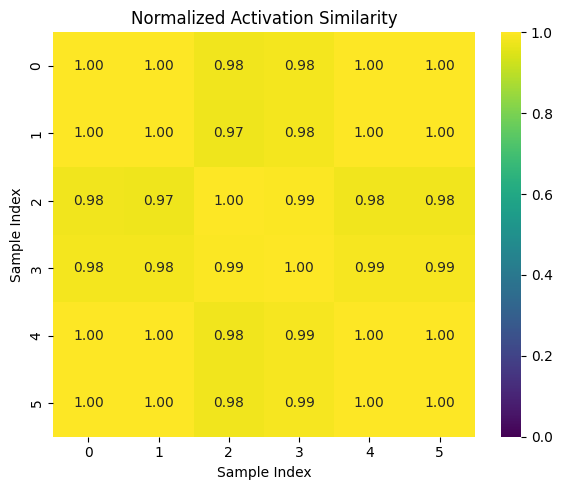

Normalized NTK Matrix:
tensor([[ 1.0000,  0.9024, -0.0163,  0.2450,  0.8777,  0.8762],
        [ 0.9024,  1.0000, -0.0071,  0.2513,  0.9088,  0.8994],
        [-0.0163, -0.0071,  1.0000,  0.0964, -0.0118, -0.0088],
        [ 0.2450,  0.2513,  0.0964,  1.0000,  0.2469,  0.2342],
        [ 0.8777,  0.9088, -0.0118,  0.2469,  1.0000,  0.9023],
        [ 0.8762,  0.8994, -0.0088,  0.2342,  0.9023,  1.0000]],
       device='mps:0')


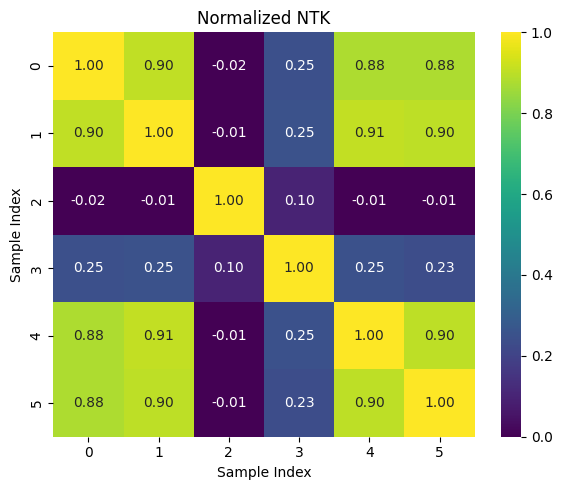

Normalized SAE Correlation Matrix:
tensor([[1.0000, 0.9998, 0.9724, 0.9810, 0.9992, 0.9993],
        [0.9998, 1.0000, 0.9696, 0.9786, 0.9991, 0.9992],
        [0.9724, 0.9696, 1.0000, 0.9964, 0.9750, 0.9745],
        [0.9810, 0.9786, 0.9964, 1.0000, 0.9835, 0.9830],
        [0.9992, 0.9991, 0.9750, 0.9835, 1.0000, 0.9999],
        [0.9993, 0.9992, 0.9745, 0.9830, 0.9999, 1.0000]], device='mps:0')


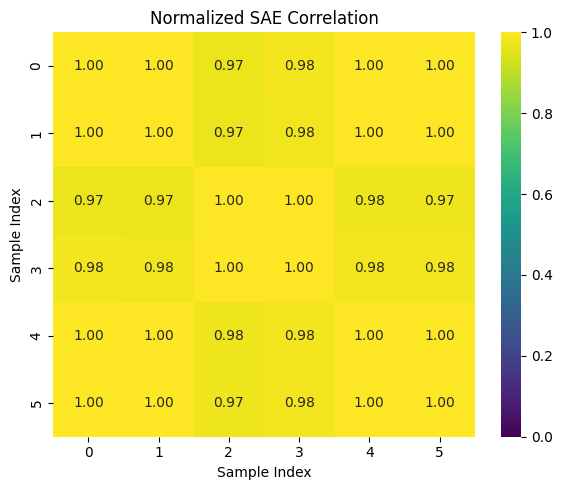

In [6]:

# Device info
device, device_name = get_device(skip_apple_silicon=False)
print(f"Using device: {device_name}")

# Load GPT2 model and tokenizer
model, tokenizer = load_gpt2_model(device)
tokenizer.pad_token = tokenizer.eos_token  

# Define tinystories dataset (dummy examples; replace with real tinystories if available)
# stories = [
#     "Once upon a time, there was a little kitten who loved adventures.",
#     "In a distant land, a brave knight fought dragons to protect his kingdom.",
#     "A young girl discovered a secret garden hidden behind the old mansion.",
#     "Deep in the forest, mysterious creatures whispered ancient tales.",
#     "On a stormy night, a group of friends gathered to share ghost stories."
# ]


stories = [
    # Pair 1: Kitten adventures
    "This plasticity is independent of changes in cortical feedback and requires proper retinogeniculate refinement.",
    "his study uncovers a brain region regulating ejaculation, extending beyond spinal mechanisms.",
    
    # # Pair 2: Knight and dragons
    # "In a distant land, a brave knight fought dragons to protect his kingdom from dark forces.",
    # "In a faraway realm, a valiant knight battled fiery dragons to safeguard his enchanted kingdom.",
    
    # Pair 3: Secret garden
    "This was incredible. I lol’d so many times - the Hatchet book reveal, stroggie face, cameos by Winona Ryder’s child and Dilbert",
    " can’t believe I was unlucky enough to not be hiking in north phoenix that day. And I was just around the corner NOT hiking in Gilbert, too!",
    
    # # Pair 4: Forest tales
    # "Deep in the forest, mysterious creatures whispered ancient tales by a shimmering stream.",
    # "Within the heart of the woods, enigmatic beings softly recited timeless legends near a glowing brook.",
    
    # Pair 5: Ghost stories
    "On a stormy night, a group of friends gathered to share ghost stories around a crackling fire.",
    "During a tempestuous evening, several companions convened to recount eerie ghost tales beside a roaring bonfire."
]


# Tokenize stories with padding and truncation
encoding = tokenizer(stories, return_tensors="pt", padding=True, truncation=True)
input_ids = encoding["input_ids"].to(device)
# attention_mask is available if needed: encoding["attention_mask"].to(device)
print("Input IDs shape:", input_ids.shape)

# Extract hidden activations from a chosen layer (e.g., layer 7)
layer_index = 7  # Adjust this index if desired (0: embeddings, 1-12: transformer blocks)
activations = get_activation(model, input_ids, layer_index)  # [batch_size, seq_len, hidden_size]
print(f"Activations shape from layer {layer_index}:", activations.shape)

# Compute activation similarity (pool activations over sequence length)
activation_similarity, pooled_activations = compute_activation_similarity(activations)
print("Activation similarity matrix shape:", activation_similarity.shape)

# Compute empirical NTK using language modeling loss
ntk_matrix = compute_empirical_ntk(model, input_ids)
print("NTK matrix shape:", ntk_matrix.shape)

# Train the Sparse Autoencoder on the pooled activations (each sample is now a vector of hidden_size)
input_dim = pooled_activations.size(1)
hidden_dim = 256  # Adjust hyperparameter as needed
sae_model = SparseAutoencoder(input_dim=input_dim, hidden_dim=hidden_dim, l1_lambda=1e-6).to(device)
trained_sae = train_sae(sae_model, pooled_activations, epochs=120, batch_size=2, lr=1e-3)

# Compute the SAE correlation matrix
sae_corr_matrix = compute_sae_correlation(trained_sae, pooled_activations)
print("SAE Correlation Matrix shape:", sae_corr_matrix.shape)

# Normalize matrices and visualize via heatmaps
norm_activation_similarity = normalize_matrix(activation_similarity)
norm_ntk_matrix = normalize_matrix(ntk_matrix)
norm_sae_corr_matrix = normalize_matrix(sae_corr_matrix)

print("Normalized Activation Similarity Matrix:")
print(norm_activation_similarity)
plot_heatmap(norm_activation_similarity, "Normalized Activation Similarity")

print("Normalized NTK Matrix:")
print(norm_ntk_matrix)
plot_heatmap(norm_ntk_matrix, "Normalized NTK")

print("Normalized SAE Correlation Matrix:")
print(norm_sae_corr_matrix)
plot_heatmap(norm_sae_corr_matrix, "Normalized SAE Correlation")


